In [2]:
import mne
import numpy as np
import pandas
import matplotlib
from sklearn.feature_selection import mutual_info_regression

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.autograd as autograd

# Edit this to change however many EEG files are shown.
num_eeg_files = 3

# Introduction
## Topic : Dependency Estimation in EEG Time-Series Data Using Mutual Information Neural Estimation (MINE)

```For this task, I plan to use an EEG dataset that contains multichannel recordings. A strong candidate is the PhysioNet EEG Motor Movement/Imagery Dataset. This dataset is publicly available and wellknown for its application in brain–computer interface research. It contains time-series recordings from multiple EEG channels, which makes it ideal for applying mutual information estimation to study inter-channel dependencies.```

## Approach
    o Pre-process the EEG time-series data (filtering, segmentation, and normalization).
    o Implement a statistics network (as per MINE) using a deep learning framework to compute the lower-bound on mutual information.
    o Evaluate and compare the MINE estimator with classical methods (e.g., k-NN based MI estimators) on synthetic examples and on real EEG data.

## Framework 
```I plan to implement the method in JupyterLab using a deeplearning library for building and training the neural network models.```

## Timeline
    • Week 1–2: Data acquisition and pre-processing of EEG signals.
    • Week 3–4: Develop and test the MINE implementation on synthetic time-series data to validate the estimator.
    • Week 5–6: Apply the estimator on the EEG dataset, run experiments, and perform analysis of inter-channel dependencies.
    • Week 7: Compile results, prepare visualizations, and draft the final report.

```I expect that the project will demonstrate that MINE can capture and quantify the nonlinear dependencies between EEG channels more effectively than traditional linear or nonparametric methods. The anticipated outcomes include:```

    • A set of estimated mutual information values between pairs of EEG channels.
    • Insights into which channels exhibit strong dependencies (potentially indicating synchronized or functionally connected brain regions).
    • An evaluation of the robustness and scalability of the MINE approach for high-dimensional time-series data.
    • The findings will serve as a preliminary step toward leveraging mutual information for feature selection, network connectivity analysis, and potentially improved performance in downstream tasks like classification or brain–computer interface applications.

```The findings will serve as a preliminary step toward leveraging mutual information for feature selection, network connectivity analysis, andpotentially improved performance in downstream tasks like classification or brain–computer interface applications.```

# Data Preprocessing

To start, we will pre-process our EEG time-series Data.

In doing a sample batch of joint and marginal, we hope to get our MINE trained to distinguish the diferrence between the two different samples.
The neural network will receive both types, learning to estimate the mutual information between our X and Y values.

Our joint data will be more DEPENDENT. While the marginal data will be more INDEPENDENT.

In [6]:
# This function is going to help us grab random samples from our batch information
# To start, we will randomly grab 150 samples
'''
data: Our array of (n_samples, 2) representing two random variables. Which are our pairs of EEG channel values
batch_size: How many samples we want to draw from each batch. Default value is going to be 150
sample_mode: What kind of sample we want to run. Typically either real samples ('joint'), or modified samples ('marginal')
'''
def sample_batch(data, batch_size = 150, sample_mode = 'joint'):
    # 'joint' runs a batch from our joint distribution P(X, Y)
    if sample_mode == 'joint':
        # Joint Sampling
        # We are taking full rows (x and y values) from the data
        index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        batch = data[index]

    # 'marginal' runs a batch from our product of marginals P(X) | P(Y)
    # This is basically our 'fake joint distribution' to help contrast with our main model
    else:
        # Our x values are going to come from the joint_index
        joint_index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        # Meanwhile, our y values are going to come from the marginal_index
        marginal_index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        batch = np.concatenate([data[joint_index][:, 0].reshape(-1, 1), data[marginal_index][:, 1].reshape(-1, 1)], axis = 1)
    return batch

In [7]:
# Load EEG files (example .edf file)
raw = []   # list to store raw EEG data
data_mine = []  # list to store numpy arrays of EEG signals (for MINE)
data_knn = []  # list to store numpy arrays of EEG signals (for kNN)

for x in range(num_eeg_files):
    # We are going to read and store in 5 different files of information
    r = mne.io.read_raw_edf('S001R0' + str(x + 1) + '.edf', preload = True)
    # (Optional) band-pass filter
    r.filter(1., 40.)           
    # Storing our data
    raw.append(r)               
    data_mine.append(r.get_data())  
    data_knn.append(r.get_data())  

print(raw[0].get_data())

# (Optional) downsample or segment to smaller chunks for faster experimentation
# data = data[:, :10000]  # e.g., first 10, 000 samples

Extracting EDF parameters from C:\Users\cjtob\CS4980 Project\S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)

Extracting EDF parameters from C:\Users\cjtob\CS4980 Project\S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering r

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting our seaborn extension for all of our scatter plots.
sns.set()

# MINE Architecture
## What are we trying to do?
Estimate the mutual information (MI) between two high-dimensional variables 𝑋 and 𝑌, using a neural network-based approach.

We will be doing an approach where we feed our MINE joint and marginal data from our EEG files.
The hope is to train our MINE so that it can properly distinguish between the two, where joint is the more consistent and accurate data.

Our main goal is to prove that MINE can capture and quantify the nonlinear dependencies between EEG channels more effectivelythan traditional linear or nonparametric methods. In this case, we will be testing a MINE Model with a kNN Model.
- Credit to 'sungyubkim' for the MINE reference

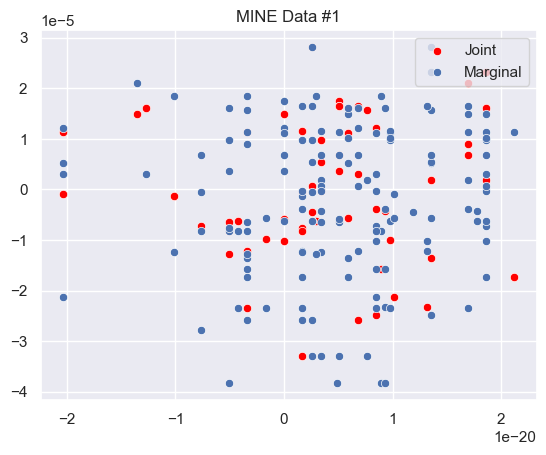

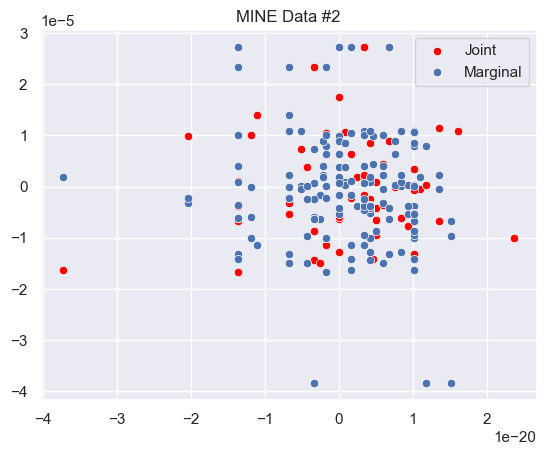

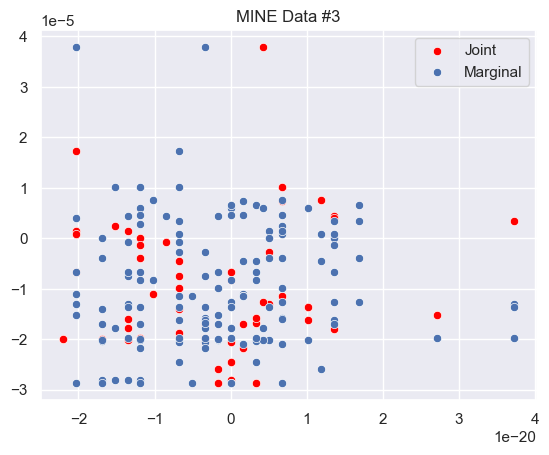

In [10]:
# This is going to help display our data between the 5 EEG files BEFORE we apply MINE to each database batch
# The batch size is going to be 150
for x in range(num_eeg_files):
    # First, we are getting our joint information
    # This is going to be the proper information from our EEG files. In other words, it will be more correlated
    joint_data = sample_batch(data_mine[x], batch_size = 150, sample_mode = 'joint')
    sns.scatterplot(x = joint_data[:, 0], y = joint_data[:, 1], color = 'red', label = 'Joint')

    # Next, we will be getting our marginal information
    # As stated, this information will be more independet, with differences between the y variables in the data
    marginal_data = sample_batch(data_mine[x], batch_size = 150, sample_mode = 'marginal')
    sns.scatterplot(x = marginal_data[:, 0], y = marginal_data[:, 1], label = 'Marginal')

    # This will be plotting our Joint and Marginal Data
    # With these plots, we will be able to see the difference between the two data sets
    plt.title("MINE Data #"  + str(x + 1))
    plt.legend(loc = 'upper right')
    plt.show()

# We should expect the information to be spread out a good amount
# After undergoing MINE, we hope to compute the lower-bound on the mutual information
# Doing so will then demonstate capturing and quantifying the nonlinear dependencies more effectively than other methods

# Defining MINE

MINE (Mutual Information Neural Estimation)

In [12]:
# Our main class for Mutual Information Neural Estimation
# It is going to be a subclass of PyTorch's Neural Network Model
class Mine(nn.Module):
    # Initialization
    '''
    self: Our MINE class
    input_size: Refers to how many inputs our model will take. For MINE, we only need 2 for X and Y
    hidden_size: How many units we want in the hidden layers of our network
    '''
    def __init__(self, input_size = 2, hidden_size = 100):
        # Initializing from out main Neural Network parent function
        super().__init__()

        # fc1, 2, 3 are going to be connected layers that take in input from our input_size and maps them to hidden_size units
        # By doing this, ...
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

        # Normal...
        # Constant...
        nn.init.normal_(self.fc1.weight, std = 0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight, std = 0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight, std = 0.02)
        nn.init.constant_(self.fc3.bias, 0)

    # This function is going to help define how data will be flowing through our network
    '''
    self: Our MINE class
    input: Just our input data that will be passed through the model
    '''
    def forward(self, input):
        # Passing input through our first layer, applying ELU activation
        output = F.elu(self.fc1(input))
        # Same thing now in the second layer
        output = F.elu(self.fc2(output))
        # One more time through the final layer, which is going to become our MI Estimate
        output = self.fc3(output)
        return output

In [13]:
# This function is going to compute the lower bound of our mutual information
# It is going to compute it between our two variables X and Y (from the data)
'''
joint: The joint distribution. This is a batch of true paired samples from the dataset (x, y). Basically our EEG signals from the channels
marginal: The marginal distribution. Our batch of paied samples where (x, y) are selected independently from different sets. Hence they're uncorrelated / unmatched
mine_net: The MINE Neural Network. We will use this to compute the estimated mutual information by passing the values through the layers (as shown in init and forward)
'''
def mutual_information(joint, marginal, mine_net):
    # This will pass our joint data through our MINE model, estimating the true Mutual Information
    t = mine_net(joint)
    
    # This will be passing our marginal data through our MINE model
    # We will estimate the mutual information from our independent pairs.
    et = torch.exp(mine_net(marginal))
    
    # This is computing the lower bound of our mutual information
    # This is the quantity that our MINE model will try to maximuze during training
    mi_lb = torch.mean(t) - torch.log(torch.mean(et))
    return mi_lb, t, et

# This function is be to help train our machine to MINE
# It works by adjusting our parameters through back propagation through the mutual information we computer and applying it to the loss function, optimizing the model
'''
batch: A tuple containing our joint and marginal data batches
mine_net: The MINE model that will be getting trained
mine_net_optim: The optimizer that we will use to update our model's parameters
ma_et: The moving average of the exponential values of the network's output for the marginal data
ma_rate: The rate at which the moving average is updated (the default value will be 0.01)
'''
def learn_mine(batch, mine_net, mine_net_optim, ma_et, ma_rate = 0.01):
    # This will be getting our joint and marginal information from the batch
    joint , marginal = batch
    
    # Here we are converting our joint and marginal batches to PyTorch tensors and moving them to our CPU
    # This wi ll allow for better gradient tracking
    joint = torch.autograd.Variable(torch.FloatTensor(joint)).to('cpu')
    marginal = torch.autograd.Variable(torch.FloatTensor(marginal)).to('cpu')

    # Now here we will compute the lower bound of mutual information between our joint and marginal batches
    mi_lb , t, et = mutual_information(joint, marginal, mine_net)
    ma_et = (1-ma_rate)*ma_et + ma_rate*torch.mean(et)
    
    # Unbiasing use moving average
    # This means we will stabilize the training by averaging out the output of the marginal samples
    loss = -(torch.mean(t) - (1/ma_et.mean()).detach()*torch.mean(et))
    # use biased estimator
    # loss = - mi_lb

    # This optimizer is used to help zero out our gradients and update the model's parameters
    mine_net_optim.zero_grad()
    autograd.backward(loss)
    mine_net_optim.step()

    # Returning our lower bound and moving average in the end
    return mi_lb, ma_et

# Training and Results

Training our MINE Model first, we are getting results through ~5000 tests while working with batch sizes of around 150
- We will be testing this on both Independent and Correlated Data
- Ideally, we will see smaller values on the Y-axis, which is going to represent our MI Estimate

In [15]:
# Now comes our main training module for MINE
# As expected, we will use this function to train our model on our given datasets
# We do this by going over several training iterations, where we generate batches of data and update our model via backpropagation
'''
data: Our (X, Y) data from the joint and marginal distributions
mine_net: Our MINE Neural Network model to be trained
mine_net_optim: Our optimizer that will update the weights during training
batch_size: However many batches we will be training our model with
iter_num: The number of iterations
log_freq: The frequency at which we will log our progress
'''
def train_MINE(data, set_num, mine_net, mine_net_optim, batch_size = 150, iter_num = int(5e+3), log_freq = int(1e+3)):
    # Data is x or y
    result = list()
    ma_et = 1.
    # We will be looping and training across multiple epochs
    for i in range(iter_num):
        # First, we wanna get 2 batches. Using our Joint and Marginal distribution
        batch = sample_batch(data, batch_size = batch_size), sample_batch(data, batch_size = batch_size, sample_mode = 'marginal')

        # With our learn_mine function, we will compute the lower bound on our MI and then update the moving average
        # Doing this will compute the loss and update our model parameters
        mi_lb, ma_et = learn_mine(batch, mine_net, mine_net_optim, ma_et)
        # Storing our results
        result.append(mi_lb.detach().cpu().numpy())
        
        # Here then we are just logging our performance and progress from the model (Remove Comment later on!)
        # if (i+1)%(log_freq) == 0:
            # print("Frequency of EEG File #" + str(set_num + 1) +": " + str(result[-1]))

    # Ultimately, result should be the list of mutual information lower bounds for each training iteration
    return result

In [16]:
# This function is going to calculate the Moving Average of a given array (a)
# The Moving Average is our method used to smooth the data, helping reduce noise, and thus making things easier to identify.
'''
a: The input array for calculating the moving average
window_size: The size of the window over which the moving average will be calculated
'''
def ma(a, window_size = 100):
    return [np.mean(a[i:i+window_size]) for i in range(0, len(a)-window_size)]

In [17]:
# Now we can start training our independent data!
result_indep_MINE = []
# Here we are going to initialize our MINE model with out CPU
mine_net_indep = Mine().to('cpu')
# This one on the other hand, is a different model, as it updates our old one with a different learning rate of 1e-3
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr = 1e-3)
for x in range(num_eeg_files):
    # Here now we are going to get out sample data
    sample = data_mine[x] 
    # Choose two channels only, for example channel 0 and channel 1
    sample_2d = sample[:, [0, 1]]  # Now shape is (n_times, 2)

    # With this information now, the train function is called. This performs that actual training of our MINE model using the data and optimizer
    # After the training, the results (our MI estimates) are appeneded to a list for data gathering
    trained_MINE_sample = train_MINE(sample_2d, x, mine_net_indep, mine_net_optim_indep)
    result_indep_MINE.append(trained_MINE_sample)

### Plotting Information

Results from EEG File #1: 7.570399e-09
Results from EEG File #2: -2.220113e-09
Results from EEG File #3: 1.8887951e-09


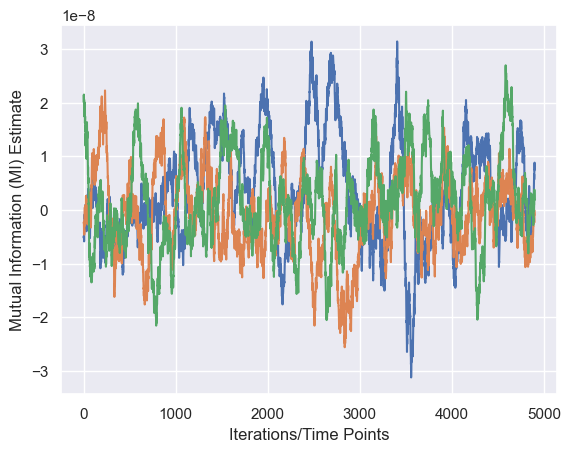

In [19]:
# Plotting out our results the calculated Moving Averages of our MINE results from the first x files we are reading
for x in range(num_eeg_files):
    # This is our Moving Average calculation here. Smoothing out our data as we graph it
    result_indep_MINE_ma = ma(result_indep_MINE[x])
    print("Results from EEG File #" + str(x + 1) + ": " + str(result_indep_MINE_ma[-1]))
    plt.plot(range(len(result_indep_MINE_ma)), result_indep_MINE_ma, label = "EEG File #" + str(x))

# print(result_indep_MINE_ma)
plt.xlabel("Iterations/Time Points")  # X-axis label
plt.ylabel("Mutual Information (MI) Estimate")  # Y-axis label
plt.show()

In [20]:
# Here we will focus more on training the MINE model on correlated data from 5 sets of EEG data
# This is our correlated data as which we will compare with our independent data
result_cor_MINE = []
for x in range(num_eeg_files):
    # Choose two channels only, for example channel 0 and channel 1
    sample = data_mine[x]  # shape: (n_times, n_channels)
    sample_2d = sample[:, [0, 1]]  # Now shape is (n_times, 2)

    # Once again getting our MINE Model and moving it to the CPU
    mine_net_cor = Mine().to('cpu')
    # We're going to add the optimized version again, with the learning rate of 1e-3
    mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr = 1e-3)
    result_cor_MINE.append(train_MINE(sample_2d, x, mine_net_cor, mine_net_optim_cor))

Results from EEG File #1: -2.3483581e-08
Results from EEG File #2: -3.1658225e-09
Results from EEG File #3: 2.5350402e-10


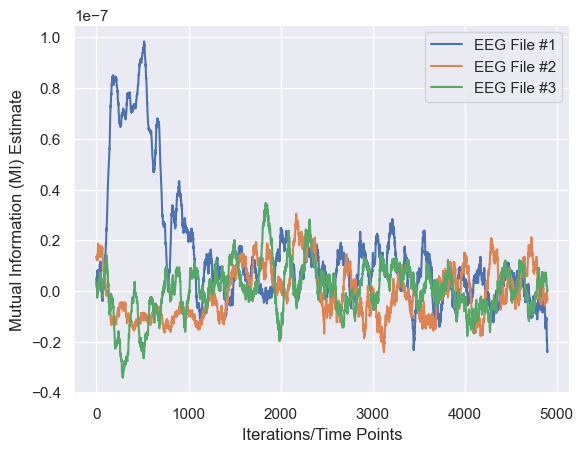

In [21]:
# Plotting out our results the calculated Moving Averages of our MINE results from the first x files we are reading
# Again, this will be our correlated data, not our independent data
result_cor_MINE_ma = []
for x in range(num_eeg_files):
    # This is our Moving Average calculation here. Smoothing out our data as we graph it
    result_cor_MINE_ma.append(ma(result_cor_MINE[x]))
    print("Results from EEG File #" + str(x + 1) + ": " + str(result_cor_MINE_ma[x][-1]))
    plt.plot(range(len(result_cor_MINE_ma[x])), result_cor_MINE_ma[x], label = "EEG File #" + str(x + 1))
    plt.legend()

plt.xlabel("Iterations/Time Points")  # X-axis label
plt.ylabel("Mutual Information (MI) Estimate")  # Y-axis label
plt.show()

# MINE Tests and Comparisons: kNN

I expect that the project will demonstrate that MINE can capture and quantify the nonlinear dependencies between EEG channels more effectively than traditional linear or nonparametric methods. The anticipated outcomes include:
- A set of estimated mutual information values between pairs of EEG channels.
- Insights into which channels exhibit strong dependencies (potentially indicating synchronized or functionally connected brain regions).
- An evaluation of the robustness and scalability of the MINE approach for high-dimensional time-series data.

We will now compare MINE alongside other estimators on synthetic data and examples AND and our real EEG data.

We plan to compare it to a classical k-NN based Mi estimator
- Credit to 'chingisooinar' for the reference

In [23]:
# Importing everything we need for the KNN Classifier
from math import sqrt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression

In [24]:
# Simulate training iterations for kNN MI Estimator
def train_KNN_MI(data, iter_num=int(5e+3), batch_size=150, sample_mode = 'joint'):
    result = []
    scaler = MinMaxScaler()
    # Normalize each channel to [0, 1]
    data = scaler.fit_transform(data)

    for _ in range(iter_num):
        # Randomly sample indices
        index = np.random.choice(range(data.shape[0]), size=batch_size, replace = data.shape[0] < batch_size)
        # batch = data[index]

        batch = sample_batch(data, batch_size, sample_mode)
        # sample_batch(data, batch_size = batch_size, sample_mode = 'marginal')
        # marginal_data_mine = sample_batch(data_mine[x], batch_size = 150, sample_mode = 'marginal')
        # joint_data_mine = sample_batch(data_mine[x], batch_size = 150, sample_mode = 'joint')

        # Separate X and Y from the batch
        x = batch[:, 0].reshape(-1, 1)
        y = batch[:, 1]

        # Estimate MI using sklearn's kNN-based estimator
        mi = mutual_info_regression(x, y, n_neighbors=5, random_state=0)[0]
        result.append(mi)
    return result

### Plotting Information

In [26]:
# Store raw kNN MI values for each EEG file
result_indep_KNN_MI = []

for x in range(num_eeg_files):
    sample = data_knn[x]
    sample_2d = sample[:, [0, 1]]
    result_indep_KNN_MI.append(train_KNN_MI(sample_2d, sample_mode = 'joint'))

Final kNN MI Estimate (Moving Avg) for EEG File #1: 0.0008788805634651986
Final kNN MI Estimate (Moving Avg) for EEG File #2: 0.00021452524017519847
Final kNN MI Estimate (Moving Avg) for EEG File #3: 0.0014862992744701443


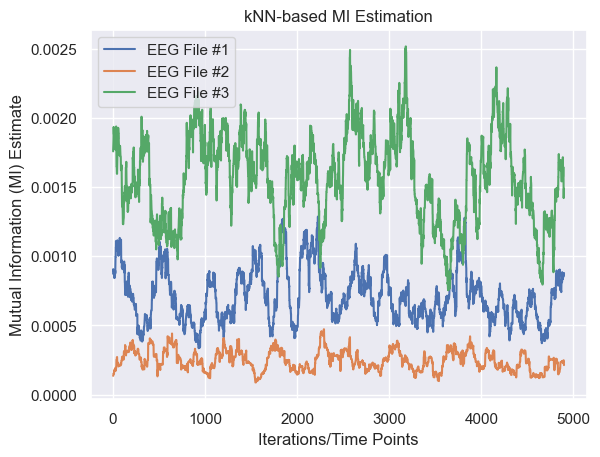

In [27]:
result_indep_KNN_MI_ma = []

for x in range(num_eeg_files):
    result_indep_KNN_MI_ma.append(ma(result_indep_KNN_MI[x]))
    print("Final kNN MI Estimate (Moving Avg) for EEG File #" + str(x + 1) + ": " + str(result_indep_KNN_MI_ma[x][-1]))
    plt.plot(range(len(result_indep_KNN_MI_ma[x])), result_indep_KNN_MI_ma[x], label = f"EEG File #{x + 1}")

plt.xlabel("Iterations/Time Points")
plt.ylabel("Mutual Information (MI) Estimate")
plt.title("kNN-based MI Estimation")
plt.legend()
plt.show()

In [28]:
# Store raw kNN MI values for each EEG file
result_cor_KNN_MI = []

for x in range(num_eeg_files):
    sample = data_knn[x]
    sample_2d = sample[:, [0, 1]]
    result_cor_KNN_MI.append(train_KNN_MI(sample_2d, sample_mode = 'marginal'))

Final kNN MI Estimate (Moving Avg) for EEG File #1: 0.0008653523863827273
Final kNN MI Estimate (Moving Avg) for EEG File #2: 0.0003609151537886146
Final kNN MI Estimate (Moving Avg) for EEG File #3: 0.0015194352372034437


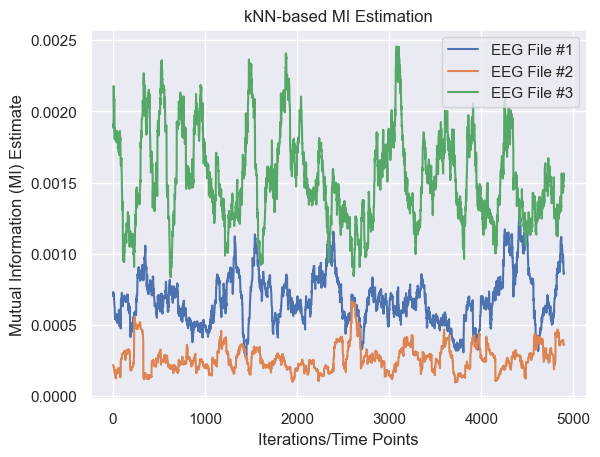

In [29]:
result_cor_KNN_MI_ma = []

for x in range(num_eeg_files):
    result_cor_KNN_MI_ma.append(ma(result_cor_KNN_MI[x]))
    print("Final kNN MI Estimate (Moving Avg) for EEG File #" + str(x + 1) + ": " + str(result_cor_KNN_MI_ma[x][-1]))
    plt.plot(range(len(result_cor_KNN_MI_ma[x])), result_cor_KNN_MI_ma[x], label = f"EEG File #{x + 1}")

plt.xlabel("Iterations/Time Points")
plt.ylabel("Mutual Information (MI) Estimate")
plt.title("kNN-based MI Estimation")
plt.legend()
plt.show()

# Correlation Results

The mutual information estimate approaches 0 when the correlation is close to 0.
This makes sense because mutual information measures the amount of dependence between two variables. 
- Negative correlation will imply that as one of our variables increase, the other will decrease. The higher the number, the more drastic the change. Regardless, this would be a pretty poor relationship.
- Positive correlation then will imply that both variables will increase or decrease with each other. Also the higher the value, the more drastic the change. As expected, this would be a very good relationship.
- No correlation (or 0) then means that there is really no linear relationship whatsoever between the variables. In which they are most likely independent of each other.

Why does this matter then? Because High correlation would indicate a strong dependency between our two variables. Which in this case, are the EEG Channels.
- For example, if two EEG channels are strongly correlated, they are likely capturing related brain activities, such as synchronized brain regions that are functionally connected.
- So the higher the positive number, the more correlated and dependent the values are with each other

We should expect the values to drop as the correlation reaches 0, given that little to no correlation implies no linear relationship. Making it more difficult for the data to give a reasonable MI Estimation.

In [31]:
# Here, We create an array of correlation values for testing
# Our values will be ranging from -0.9 to 0.9 with 19 evenly spaced values
correlations = np.linspace(-0.9, 0.9, 19)
print(correlations)
# The generated correlation values will be used in subsequent steps for testing how the MINE model performs
# More specifically, how it performs under different levels of correlation between the data

[-0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4
  0.5  0.6  0.7  0.8  0.9]


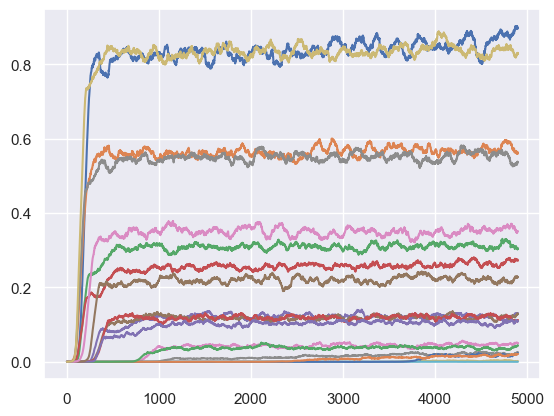

In [32]:
final_result_MINE = []
# Here, we will evaluate our MINE model by testing it across synthetic data with different correlation levels
# We will go through all 19 correlation levels
for rho in correlations:
    # For each correlation value rho, we generate synthetic data using a bi-variate normal distribution
    # Where cov = [[1, rho], [rho, 1]] sets the covariance matrix for the bivariate distribution
    # This will help determine the correlation between the two variables
    rho_data = np.random.multivariate_normal( mean = [0, 0], 
                                  cov = [[1, rho], [rho, 1]], 
                                 size = 300)

    # Once again, we will create our new instance of MINE and the Optimizer instance
    # With these, we will...
    mine_net = Mine().to('cpu')
    mine_net_optim = optim.Adam(mine_net.parameters(), lr = 1e-3)

    # Now we train the MINE model on our new, synthetic data
    result = train_MINE(rho_data, -1, mine_net, mine_net_optim)
    result_ma_MINE = ma(result)

    # We store the last value of our Moving Average
    final_result_MINE.append(result_ma_MINE[-1])
    # print(str(round(rho, 1)) + ' : ' + str(final_result_MINE[-1]))
    plt.plot(range(len(result_ma_MINE)), result_ma_MINE, label=str(rho) + " Frequency")
    # plt.legend()

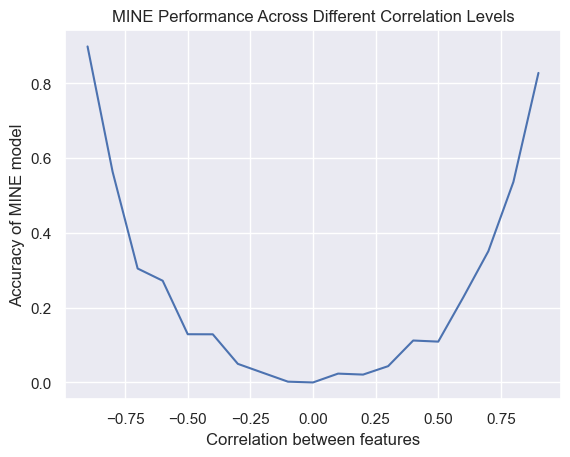

In [33]:
# Plotting our correlation results
plt.xlabel('Correlation between features')
plt.ylabel('Accuracy of MINE model')
plt.title('MINE Performance Across Different Correlation Levels')
plt.grid(True)

# print(correlations)
# print(final_result_MINE)
plt.plot(correlations, final_result_MINE)

# With this graph, we will see...

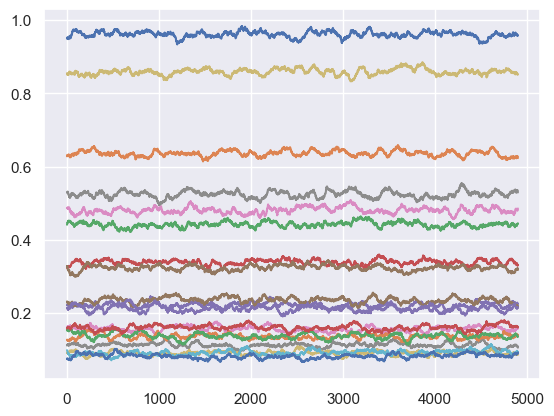

In [34]:
final_result_KNN = []

# For each correlation value rho...
for rho in correlations:
    # Generate synthetic 2D normal data with correlation rho
    rho_data = np.random.multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]],
        size=300
    )

    # Train kNN estimator over synthetic data
    result = train_KNN_MI(rho_data, sample_mode='joint')
    result_ma_KNN = ma(result)

    # Save the last moving average value
    final_result_KNN.append(result_ma_KNN[-1])

    # Plot each MI curve per rho
    plt.plot(range(len(result_ma_KNN)), result_ma_KNN, label=f"ρ = {rho}")

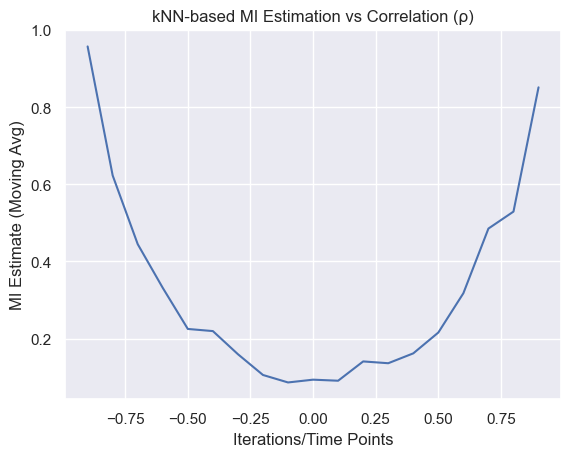

In [35]:
# Plotting our correlation results
plt.xlabel("Iterations/Time Points")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("kNN-based MI Estimation vs Correlation (ρ)")
# plt.legend()
# plt.show()
plt.grid(True)

# print(correlations)
# print(final_result_KNN)
plt.plot(correlations, final_result_KNN)

# With this graph, we will see...

## Correlated Graphs
Here we are going to compare the graphs with each other
- We see that MINE gets slightly lower values than kNN for most of the iterations.
- This helps show that...

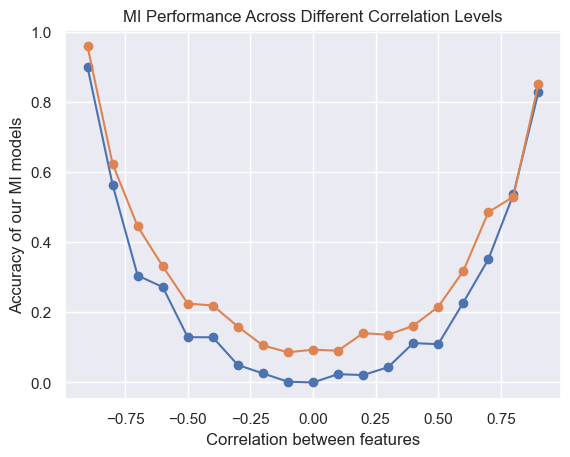

In [37]:
# Comparing the correlated Graphs as well
plt.plot(correlations, final_result_MINE, marker='o', linestyle='-', label='MINE')
plt.plot(correlations, final_result_KNN, marker='o', linestyle='-', label='kNN')
plt.xlabel('Correlation between features')
plt.ylabel('Accuracy of our MI models')
plt.title('MI Performance Across Different Correlation Levels')
plt.grid(True)
plt.show()

# Evaluation

We finish by evaluating both sides now with just Synthetic Data.

Think of this as like our base cases. We want to be both MINE and kNN with very generic data that is pretty linear overall.

This will help give us a solid baseline for our main questions like:
- Is MINE estimating MI values that match ground truth?
- How much would kNN compare when it comes to these simple checks?
- Without this, we wouldn't be able to effectively judge just how close our estimated MI is to the true MI

In [39]:
x = np.random.uniform(low=-1.,high=1.,size=3000)
f1 = x
f2 = 2*x
f3 = np.sin(x)
f4 = x**3
eps = np.random.normal(size=3000)

<Axes: >

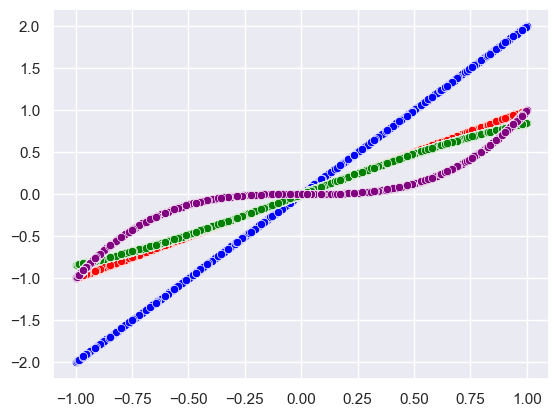

In [40]:
# Our 4 f values will resemble 4 different kinds of synthetic data
# f1 is linear 1-to-1 data
sns.scatterplot(x = x, y = f1, color = 'red')
# f2 is linear 2-to-1 data
sns.scatterplot(x = x, y = f2, color = 'blue')
# f3 is the sin of our data
sns.scatterplot(x = x, y = f3, color = 'green')
# f4 is the our data cubed
sns.scatterplot(x = x, y = f4, color = 'purple')

In [41]:
# Preparing our checks
# The sigmas will represent our different noise levels for different tests
# The higher values will mean more distortion and thus weaker dependecies between x and f
sigmas = np.linspace(0.0,0.9,10)
fs = [f1, f2, f3, f4]
print(sigmas)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


Text(0.5, 1.0, 'MINE MI Estimation on Synthetic Features with Noise')

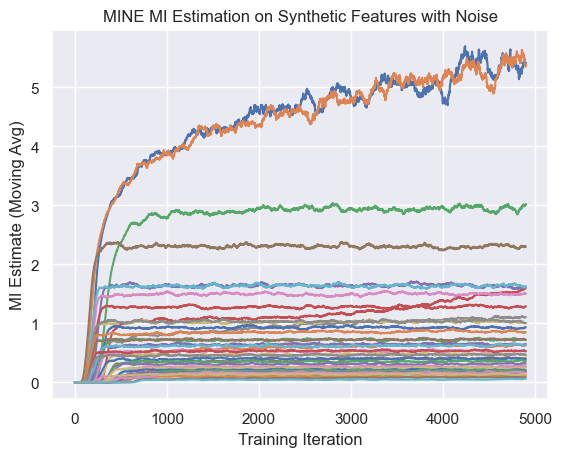

In [42]:
# First, with our MINE Model
final_result_MINE = []
for sigma in sigmas:
    for fi, f in enumerate(fs):
        # Generating our synthetic training dataset
        # X represents our original value, while the Y will be a noisier version of f, making it more distorted
        data = np.concatenate([x.reshape(-1,1), (f + sigma * eps).reshape(-1,1)], axis=1)

        # Initializing and training now with our MINE model
        mine_net = Mine().to('cpu')
        mine_net_optim = optim.Adam(mine_net.parameters(), lr=1e-3)
        result = train_MINE(data, -1, mine_net, mine_net_optim, iter_num = int(5e+3))

        # Calculating the moving average of our result befor appending it
        result_ma = ma(result)
        final_result_MINE.append(result_ma[-1])
        # print(str(sigma) + ', ' + str(fi) +' : ' + str(final_result[-1]))
        if (sigma < 0.3):
            # We will display the first few sigmas to get an idea
            plt.plot(range(len(result_ma)), result_ma, label = 'SIGMA: ' + str(sigma))
        else:
            plt.plot(range(len(result_ma)), result_ma)

# What should we expect from our graph?
# X is going to display all of our training iterations over time
# Y is going to display the MI Estimate. This is the correlation between X and f(X) + noise
plt.xlabel("Training Iteration")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("MINE MI Estimation on Synthetic Features with Noise")

# The higher the values, the stronger the MI
# Where as the lower the values, the more difficult it is to detect a signal or connection

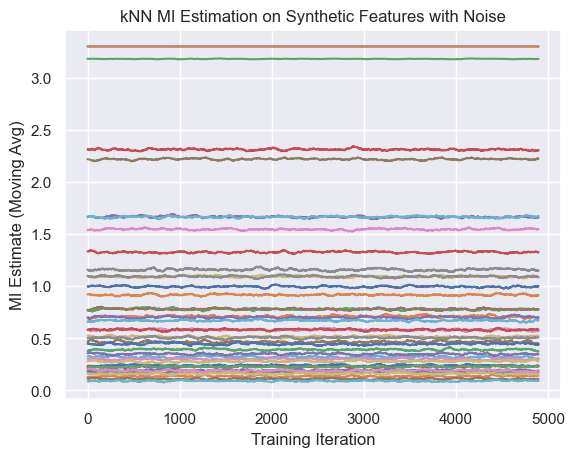

In [43]:
# Next, we will do the same thing with our kNN Model
final_result_KNN = []
for sigma in sigmas:
    for fi, f in enumerate(fs):
        # Create synthetic dataset with noise
        data = np.concatenate([x.reshape(-1, 1), (f + sigma * eps).reshape(-1, 1)], axis=1)

        # Train kNN-based MI estimator on synthetic data
        result = train_KNN_MI(data, iter_num=int(5e+3), batch_size=150, sample_mode='joint')
        result_ma = ma(result)

        # Store last value of the moving average
        final_result_KNN.append(result_ma[-1])

        # Plotting the MI progression for this sigma/feature
        if (sigma < 0.3):
            # We will display the first few sigmas to get an idea
            plt.plot(range(len(result_ma)), result_ma, label = 'SIGMA: ' + str(sigma))
        else:
            plt.plot(range(len(result_ma)), result_ma)

# What should we expect from our graph?
# X is going to display all of our training iterations over time
# Y is going to display the MI Estimate. This is the correlation between X and f(X) + noise
plt.xlabel("Training Iteration")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("kNN MI Estimation on Synthetic Features with Noise")
plt.show()

# Conclusion

Overall, what do we see from our graphs between MINE and kNN MI Estimation on the Synthetic Data?
- MINE typically has a higher MI estimate than kNN, going as far as ~6 while kNN remains roughly around ~3.
- There is growth for MINE as it goes through more iterations, while kNN remains around the same Estimate as it started in.

What does this mean for MINE overall (based on all graphs)? For kNN?
- For MINE, it is better at detecting higher-strength MI
    - Even better when the relationships are more clear, i.e. don't have too much noise.
    - It also handles non linear dependencies better, meaning that MINE is also more sensitive to complex linear relationships
- For KNN, it is more stable, but seemingly less dynamic than MINE
    - In our plots, KNN tends to stay closer together, but displays less resolution across the different noise levels.
    - It is stable and fast, but also pretty static with all of its results